In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('/content/drive/MyDrive/codebooster-datasets/netflix_titles.csv')

In [4]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print(f'Shape of the dataset:{df.shape}')

print(df.info())

print(df.describe())

df.columns.tolist()

Shape of the dataset:(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df.duplicated().sum().sum()

np.int64(0)

# Data Cleaning & Preprocessing

In [8]:

df['director'].fillna('Unknown',inplace=True)

df['cast'].fillna('Not Available',inplace=True)

df['country'].fillna(df['country'].mode()[0],inplace=True)

df['date_added'].fillna(df['date_added'].mode()[0],inplace=True)

df['rating'].fillna(df['rating'].mode()[0],inplace=True)

/tmp/ipykernel_2474/2023542402.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown',inplace=True)
/tmp/ipykernel_2474/2023542402.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['date_added']=pd.to_datetime(df['date_added'], format='mixed')

In [11]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [12]:
df.to_csv('netflix_titles_cleaned.csv',index=False)


# SQLite Database Integration

In [13]:
import sqlite3

In [14]:
conn=sqlite3.connect('netflix.db')

In [15]:
cleaned_df=pd.read_csv('/content/drive/MyDrive/codebooster-datasets/netflix_titles_cleaned.csv')

In [16]:
cleaned_df.to_sql('netflix_titles',
                  conn,
                  if_exists='replace',
                  index=False)

8807

In [17]:
pd.read_sql(
    "select count(*) as total_records from netflix_titles",
    conn
)

,total_records
0,8807


In [18]:
query = """
SELECT *
FROM netflix_titles
WHERE type='Movie'
LIMIT 10
"""

pd.read_sql(query,conn)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
2,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
3,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
4,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
5,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",United States,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
6,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",Not Available,United States,2021-09-22,2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
7,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",United States,2021-09-22,2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...
8,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",United States,2021-09-21,1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
9,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",United States,2021-09-21,2021,TV-Y,61 min,Children & Family Movies,From arcade games to sled days and hiccup cure...


In [19]:
query = """
SELECT title,release_year
FROM netflix_titles
ORDER BY release_year DESC
LIMIT 10
"""

pd.read_sql(query,conn)

,title,release_year
0,Blood & Water,2021
1,Ganglands,2021
2,Jailbirds New Orleans,2021
3,Kota Factory,2021
4,Midnight Mass,2021
5,My Little Pony: A New Generation,2021
6,The Great British Baking Show,2021
7,The Starling,2021
8,"Vendetta: Truth, Lies and The Mafia",2021
9,Bangkok Breaking,2021


In [20]:
query = """
SELECT country,title,director,type,rating
FROM netflix_titles
WHERE country='United States' AND type='Movie'
LIMIT 10
"""

pd.read_sql(query,conn)

,country,title,director,type,rating
0,United States,Dick Johnson Is Dead,Kirsten Johnson,Movie,PG-13
1,United States,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Movie,PG
2,United States,The Starling,Theodore Melfi,Movie,PG-13
3,United States,Confessions of an Invisible Girl,Bruno Garotti,Movie,TV-PG
4,United States,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",Movie,TV-MA
5,United States,Intrusion,Adam Salky,Movie,TV-14
6,United States,Avvai Shanmughi,K.S. Ravikumar,Movie,TV-PG
7,United States,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore",Movie,TV-Y
8,United States,Minsara Kanavu,Rajiv Menon,Movie,TV-PG
9,United States,Grown Ups,Dennis Dugan,Movie,PG-13


In [21]:
query = """
SELECT rating,
COUNT(*) total
FROM netflix_titles
GROUP BY rating
ORDER BY total DESC
"""

pd.read_sql(query,conn)

,rating,total
0,TV-MA,3211
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


In [22]:
query = """
SELECT title,release_year
FROM netflix_titles
WHERE type='Movie'
AND release_year > 2018
"""
pd.read_sql(query,conn)

,title,release_year
0,Dick Johnson Is Dead,2020
1,My Little Pony: A New Generation,2021
2,The Starling,2021
3,Je Suis Karl,2021
4,Confessions of an Invisible Girl,2021
...,...,...
1422,The Spy Who Fell to Earth,2019
1423,Trixie Mattel: Moving Parts,2019
1424,Westside vs. the World,2019
1425,Wish Man,2019


#SQL-Based Transformation

In [23]:
transformed_df = pd.read_sql(query,conn)

In [24]:
transformed_df.to_csv(
    "netflix_transformed.csv",
    index=False
)

#ETL Pipeline

In [25]:
#extract
df=pd.read_csv('/content/drive/MyDrive/codebooster-datasets/netflix_titles.csv')

In [26]:
#transform
df.drop_duplicates(inplace=True)

df.fillna('Unknown',inplace=True)


In [27]:
#load
df.to_csv(
        "etl_netflix.csv",
        index=False
    )

#PySpark Medallion Architecture

In [28]:
!pip install pyspark --quiet

In [29]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
        .appName("NetflixMedallion") \
        .getOrCreate()

In [30]:
#bronze layer
bronze_df=spark.read.csv('/content/drive/MyDrive/codebooster-datasets/netflix_titles_cleaned.csv',header=True,inferSchema=True)

In [31]:
bronze_df.printSchema()

root
 |-- show_id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- director: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- country: string (nullable = true)
 |-- date_added: string (nullable = true)
 |-- release_year: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- listed_in: string (nullable = true)
 |-- description: string (nullable = true)



In [32]:
bronze_df.show(5)
print(bronze_df.columns)

+-------+-------+--------------------+---------------+--------------------+-------------+----------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+----------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|       Not Available|United States|2021-09-25|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|        Unknown|Ama Qamata, Khosi...| South Africa|2021-09-24|        2021| TV-MA|2 Seasons|International TV ...|After crossing pa...|
|     s3|TV Show|           Ganglands|Julien Leclercq|Sami Bouajila, Tr...|United States|2021-09-24|        2021| TV-MA| 1 Season|Crime

In [39]:
silver_df.write \
    .mode("overwrite") \
    .parquet("silver_layer")

In [40]:
silver_df.show(5)
silver_df.printSchema()

+-------+-------+--------------------+----------------+--------------------+-------------+----------+------------+------+--------+--------------------+--------------------+
|show_id|   type|               title|        director|                cast|      country|date_added|release_year|rating|duration|           listed_in|         description|
+-------+-------+--------------------+----------------+--------------------+-------------+----------+------------+------+--------+--------------------+--------------------+
|   s211|  Movie|          Ragini MMS| Pawan Kripalani|Kainaz Motivala, ...|        India|2021-08-27|        2011| TV-MA|  93 min|Horror Movies, In...|A couple out to h...|
|   s642|  Movie|    Sisters on Track|         Unknown|       Not Available|United States|2021-06-24|        2021|    PG|  97 min|Documentaries, Sp...|Three track star ...|
|   s673|  Movie|Mobile Suit Gunda...|Yoshiyuki Tomino|Toru Furuya, Shui...|United States|2021-06-19|        1988| TV-14| 120 min|Actio

In [41]:
gold_df = silver_df.groupBy("type").count()

gold_df.show()

+-------------+-----+
|         type|count|
+-------------+-----+
|         NULL|    1|
|      TV Show| 2676|
|        Movie| 6131|
|William Wyler|    1|
+-------------+-----+



In [42]:
gold_df.write \
    .mode("overwrite") \
    .parquet("gold_layer/type_analysis")

In [43]:
rating_gold = silver_df.groupBy("rating").count()

rating_gold.show()

+--------------------+-----+
|              rating|count|
+--------------------+-----+
|    Shavidee Trotter|    1|
|                TV-Y|  307|
|                  UR|    3|
|Classic Movies, D...|    1|
|                  PG|  286|
|               TV-MA| 3199|
|     Jowharah Jones"|    1|
|            TV-Y7-FV|    6|
|                2006|    1|
|              84 min|    1|
|             Unknown|    2|
|                  NR|   80|
|               TV-PG|  862|
|               NC-17|    3|
|                   R|  796|
|                   G|   41|
|                2021|    2|
|               TV-14| 2158|
|                TV-G|  220|
|     Kristen Schaal"|    1|
+--------------------+-----+
only showing top 20 rows


In [44]:
country_gold = silver_df.groupBy("country").count() \
                        .orderBy("count", ascending=False)

country_gold.show()

+--------------------+-----+
|             country|count|
+--------------------+-----+
|       United States| 3635|
|               India|  972|
|      United Kingdom|  419|
|               Japan|  245|
|         South Korea|  199|
|              Canada|  181|
|               Spain|  145|
|              France|  123|
|              Mexico|  110|
|               Egypt|  106|
|              Turkey|  105|
|             Nigeria|   93|
|           Australia|   87|
|              Taiwan|   81|
|           Indonesia|   79|
|              Brazil|   77|
|United Kingdom, U...|   75|
|         Philippines|   75|
|United States, Ca...|   73|
|             Germany|   67|
+--------------------+-----+
only showing top 20 rows


In [45]:
country_gold.write \
    .mode("overwrite") \
    .parquet("gold_layer/country_analysis")

In [46]:
year_gold = silver_df.groupBy("release_year").count() \
                     .orderBy("release_year")

year_gold.show()

+-----------------+-----+
|     release_year|count|
+-----------------+-----+
|             NULL|    2|
|   Charles Rocket|    1|
|          Dr. Dre|    1|
|   Francis Weddey|    1|
|     Imanol Arias|    1|
|      Jade Eshete|    1|
| Kristen Johnston|    1|
| Marquell Manning|    1|
|       Nick Kroll|    1|
|    Nse Ikpe-Etim|    1|
|       Paul Sambo|    1|
|   Peter Ferriero|    1|
|     Ted Ferguson|    1|
| Álvaro Cervantes|    1|
|             1925|    1|
|             1942|    2|
|             1943|    3|
|             1944|    2|
|             1945|    4|
|             1946|    2|
+-----------------+-----+
only showing top 20 rows


In [47]:
year_gold.write \
    .mode("overwrite") \
    .parquet("gold_layer/year_analysis")

In [48]:
spark.read.parquet(
    "gold_layer/type_analysis"
).show()

+-------------+-----+
|         type|count|
+-------------+-----+
|         NULL|    1|
|      TV Show| 2676|
|        Movie| 6131|
|William Wyler|    1|
+-------------+-----+



#CSV vs Parquet Comparison

In [50]:
import os

csv_size = os.path.getsize(
    "/content/drive/MyDrive/codebooster-datasets/netflix_titles_cleaned.csv"
)

print("CSV Size:", csv_size,"bytes")

CSV Size: 3380478 bytes


In [51]:
parquet_size = 0

for root, dirs, files in os.walk("silver_layer"):
    for file in files:
        parquet_size += os.path.getsize(
            os.path.join(root, file)
        )

print("Parquet Size:", parquet_size, "bytes")

Parquet Size: 2052128 bytes


#Parquet to Pandas

In [52]:
parquet_df = spark.read.parquet(
    "silver_layer"
)

In [53]:
pandas_df = parquet_df.toPandas()

In [54]:
pandas_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s211,Movie,Ragini MMS,Pawan Kripalani,"Kainaz Motivala, Rajkummar Rao, Rajat Kaul, Ja...",India,2021-08-27,2011,TV-MA,93 min,"Horror Movies, International Movies",A couple out to have a sensuous weekend at a h...
1,s642,Movie,Sisters on Track,Unknown,Not Available,United States,2021-06-24,2021,PG,97 min,"Documentaries, Sports Movies",Three track star sisters face obstacles in lif...
2,s673,Movie,Mobile Suit Gundam: Char's Counterattack,Yoshiyuki Tomino,"Toru Furuya, Shuichi Ikeda, Hirotaka Suzuoki, ...",United States,2021-06-19,1988,TV-14,120 min,"Action & Adventure, Anime Features, Internatio...","Thirteen years after the war, the Neo Zeon arm..."
3,s754,TV Show,"Newly Rich, Newly Poor",Unknown,"Martín Karpan, Carolina Acevedo, Jhon Álex Tor...",Colombia,2021-06-06,2007,TV-MA,1 Season,"International TV Shows, Romantic TV Shows, Spa...","After learning they were switched at birth, we..."
4,s1160,Movie,Black Is Beltza,Fermín Muguruza,"Unax Ugalde, Isaach De Bankolé, Iseo, Sergi Ló...",United States,2021-03-26,2018,TV-MA,87 min,"Dramas, International Movies",A young Basque man is radicalized in 1960s Ame...


In [55]:
print(pandas_df.shape)

(8809, 12)


#Data Visualization

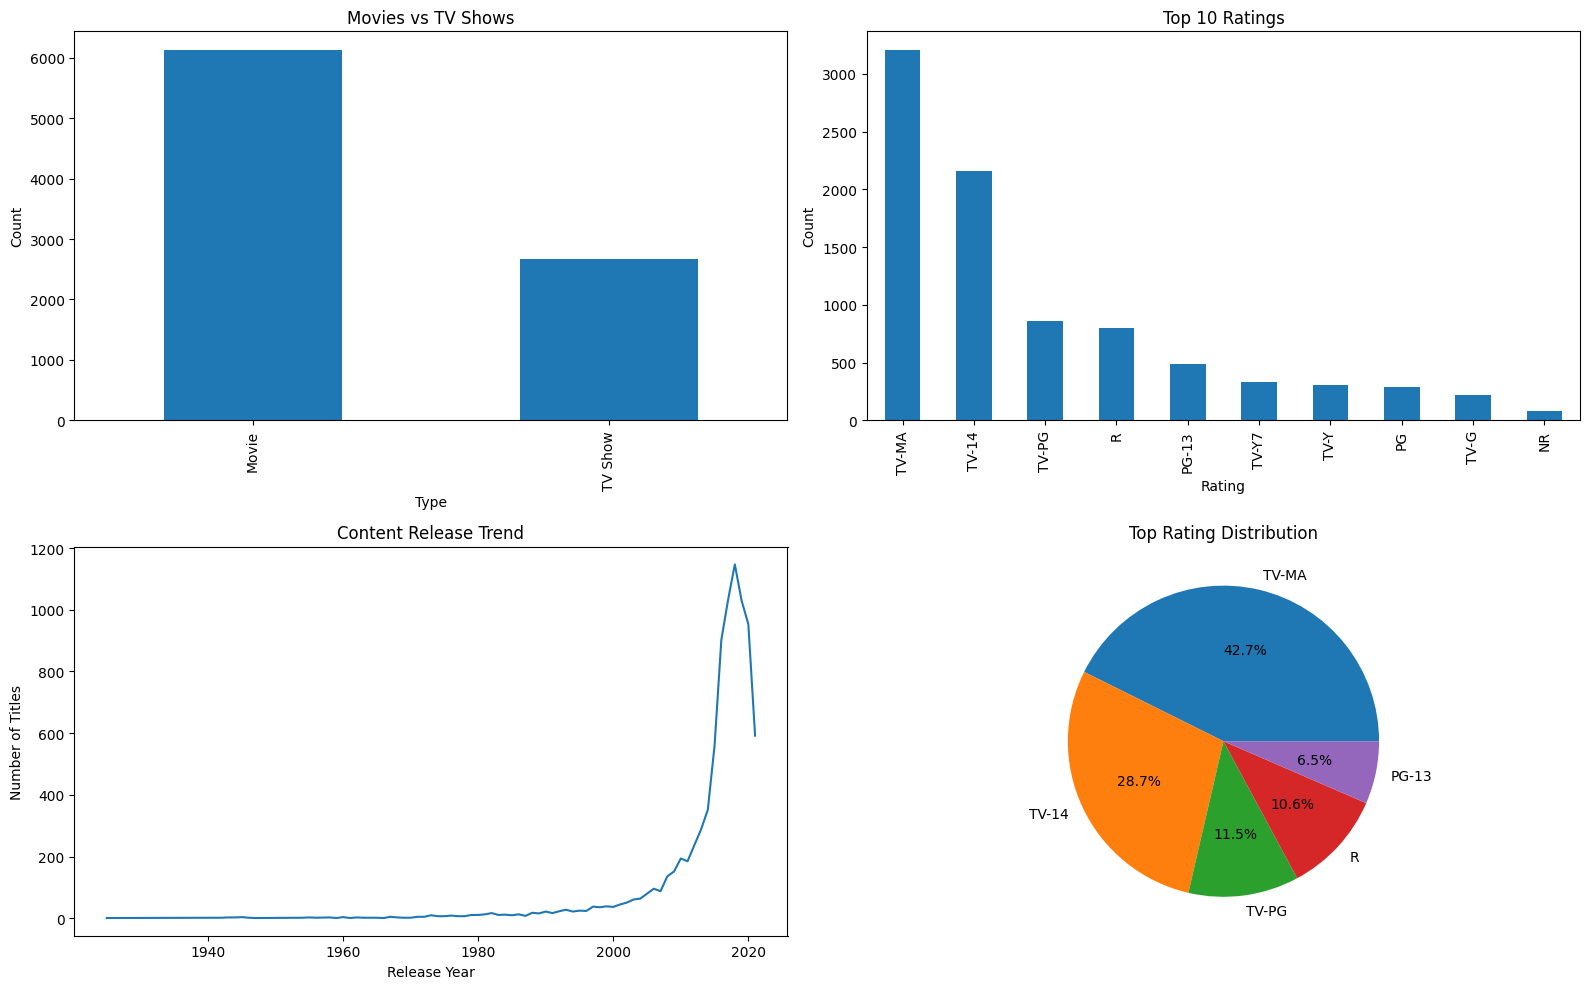

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))

# ---------------------------
# Chart 1: Movies vs TV Shows
# ---------------------------
plt.subplot(2,2,1)

df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')

# ---------------------------
# Chart 2: Top 10 Ratings
# ---------------------------
plt.subplot(2,2,2)

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

# ---------------------------
# Chart 3: Release Trend
# ---------------------------
plt.subplot(2,2,3)

df['release_year'].value_counts() \
                  .sort_index() \
                  .plot(kind='line')

plt.title('Content Release Trend')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

# ---------------------------
# Chart 4: Rating Distribution
# ---------------------------
plt.subplot(2,2,4)

df['rating'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Top Rating Distribution')
plt.ylabel('')

plt.tight_layout()

plt.show()

#Machine Learning Model

In [58]:
ml_df = df[['type','release_year','rating']].copy()

In [59]:
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()
le_rating = LabelEncoder()

ml_df['type'] = le_type.fit_transform(
    ml_df['type']
)

ml_df['rating'] = le_rating.fit_transform(
    ml_df['rating']
)

In [60]:
X = ml_df[['release_year','rating']]

y = ml_df['type']